# Assessment 2： Neural Networks on Ocean Data

## 1 Scientific Background

### 1.1 Argo Program$^{[1]}$

Argo is an international program that deploys a global array of autonomous, free-drifting profiling floats throughout the global ocean. These floats are carried passively by ocean currents, conduct repeated vertical profiles between **the surface and 2,000 meters depth**, collect high-precision **temperature** and **salinity** measurements, and deliver over 100,000 standardized profiles plus reference velocity data annually. As a core component of the Global Ocean Observing System, it resolves the critical spatiotemporal limitations of traditional ship-based observations. The Argo dataset provides a consistent source of observations for various research applications in oceanography$^{[2]}$. It has been used to quantify global ocean heat uptake$^{[3,4]}$, identify the large-scale ocean circulation shifts$^{[5]}$ and observe the impact of equatorial tropical cyclones on upper ocean temperature and salinity$^{[6]}$.

The combination of temperature and salinity determines seawater density, which serves as a primary driver for the global thermohaline circulation. Within specific water masses, these two parameters are closely coupled along characteristic curves in temperature-salinity space, often referred to as water-mass lines. This relationship suggests that salinity is at least partially predictable based on temperature observations. Nevertheless, the correlation between these variables is non-linear and exhibits significant variation across different ocean basins and depths. This complexity presents a traditional challenge for non-linear regression models. In this study, we focus on the Atlantic sector to maintain a manageable data volume.

### 1.2 Marine Bacteria

This section of the data comes from a paper by Charmaine Yung$^{[7]}$. This study conducted a three-year, weekly high-resolution time-series survey at the Pifers Island Coastal Observatory (PICO) to investigate the community dynamics of temperate coastal marine bacterial plankton. The study shows that the composition of the microbial community is not constantly changing, but rather a rapid transition between summer and winter communities. This seasonal transition is primarily mediated by mediated by switches between closely related taxa and temperature changes result in significant responses in the microbiome, thereby affecting biogeochemical potential.

In [1]:
# To make this notebook run on Colab, I installed some package and cloned the entire oces3301 project to load the Argo data.

!pip3 install -q cartopy zarr fsspec

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch
import seaborn as sns

import pandas as pd
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
torch.manual_seed(1234)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# load the argo data from oces3301 (Colab)
# repo_path = "/content/OCES3301_data_analysis"
# !rm -rf {repo_path}
# !git clone https://github.com/julianmak/OCES3301_data_analysis.git {repo_path}
# argo_data = xr.open_zarr("/content/OCES3301_data_analysis/GLOB_HOMOGENEOUS_variables.zarr", consolidated=False)

# load the argo data from my own computor (jupyter notebook)
argo_data = xr.open_zarr("./GLOB_HOMOGENEOUS_variables.zarr/", consolidated=False)

bacteria_loc = "https://raw.githubusercontent.com/julianmak/OCES4303_ML_ocean/refs/heads/main/PIDweekly_env_data.txt"

Using device: cuda


## 2 Argo Data

### 2.1 Preprocessing and Spatial Visualization of Atlantic Argo Data

First I performs the data quality control by filtering global Argo float observations for valid salinity ranges (25–40) and removing incomplete profiles. Then remove all incomplete profiles and apply geographic subsetting to isolate the **Atlantic** sector between longitudes -75° and 17°. The vertical depth levels are then standardized across all profiles. Finally, using Cartopy to visualize temperature and salinity fields at a specific deep-sea layer.

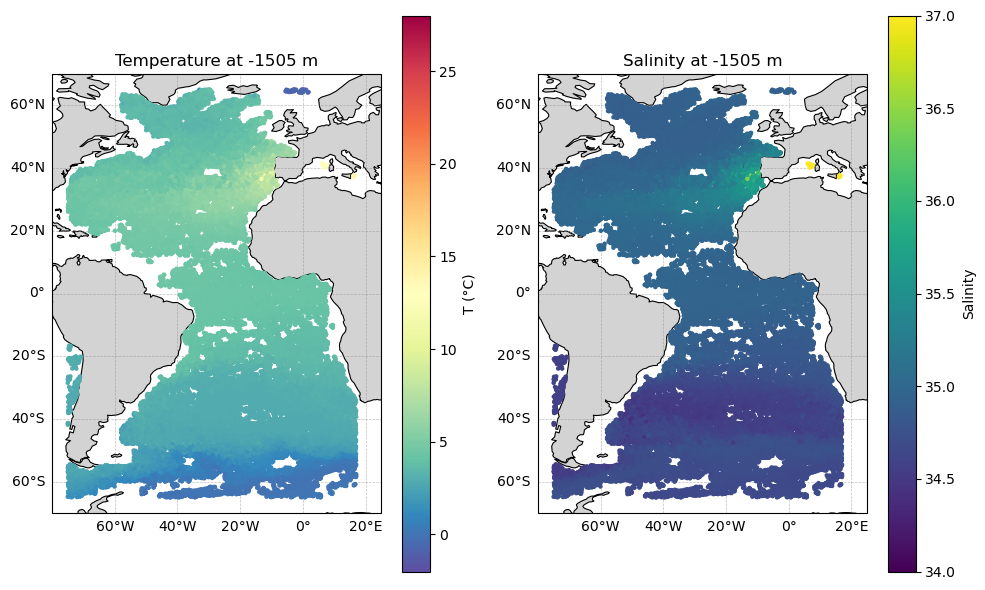

In [2]:
da_al = argo_data[["PSAL", "TEMP", "DEPTH"]]
da_s = da_al.where(((da_al.PSAL < 40.) & (da_al.PSAL > 25.)).compute(), drop=True)
da_s = da_s.dropna('N_PROF')

# Atlantic sector
da = da_s.where((da_s['LONGITUDE'] > -75.) & (da_s['LONGITUDE'] < 17.), drop=True)

data = np.stack((da.TEMP[:, :-30].values, da.PSAL[:, :-30].values), axis=2)

depth = da_s.DEPTH[:-30].values

nl = -1
fig, axes = plt.subplots(1, 2, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

axes[0].set_extent([-80, 25, -70, 70], crs=ccrs.PlateCarree())
axes[0].add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
gl0 = axes[0].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl0.top_labels = False
gl0.right_labels = False

cs0 = axes[0].scatter(da.LONGITUDE, da.LATITUDE, s=5, c=da.TEMP[:, nl], cmap='Spectral_r', vmin=-2, vmax=28, zorder=3)
axes[0].set_xlabel(r"Longitude ($^\circ$)", fontsize=12)
axes[0].set_ylabel(r"Latitude ($^\circ$)", fontsize=12)
axes[0].set_title(f"Temperature at {da_s.DEPTH[nl].values:.0f} m", fontsize=12)
plt.colorbar(cs0, ax=axes[0], label="T (°C)")
axes[0].grid(lw=0.4, zorder=0)
 
axes[1].set_extent([-80, 25, -70, 70], crs=ccrs.PlateCarree())
axes[1].add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
gl0 = axes[1].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl0.top_labels = False
gl0.right_labels = False

cs1 = axes[1].scatter(da.LONGITUDE, da.LATITUDE, s=5, c=da.PSAL[:, nl], cmap='viridis', vmin=34, vmax=37, zorder=3)
axes[1].set_xlabel(r"Longitude ($^\circ$)", fontsize=12)
axes[1].set_ylabel(r"Latitude ($^\circ$)", fontsize=12)
axes[1].set_title(f"Salinity at {da_s.DEPTH[nl].values:.0f} m", fontsize=12)
plt.colorbar(cs1, ax=axes[1], label=r"Salinity")
axes[1].grid(lw=0.4, zorder=0)

plt.tight_layout()
plt.show()

Next, I wanted to examine the overall temperature and salinity distribution of the data using **T-S diagram**. First, I randomly selected 2000 representative profiles from all data, flattened them into point clouds and generated a T-S diagram. The colors in the diagram represent depth, used to identify water masses at different depths. Second, I selected a vertical cross-section from one location to observe the specific stratification of the water column.

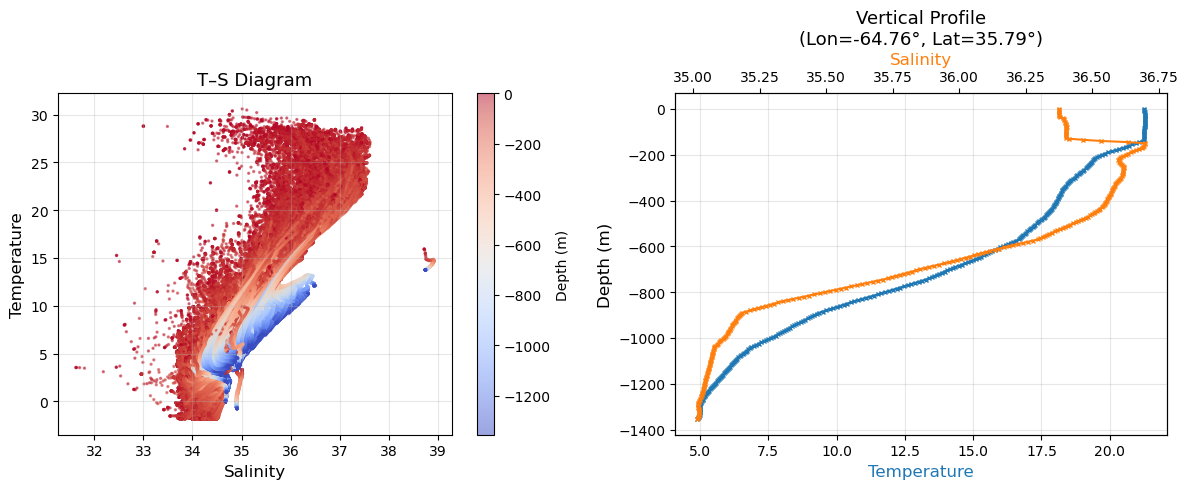

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# T-S Diagram: 
# 1. Randomly select 2000 profile. 
# 2. Flattening the T and S to vector. 
# 3. Copying the depth 2000 times to creat a depth veator of same length as the T and S
# 4. Using a bool mask to remove NaN or infinite values.
rng = np.random.default_rng(SEED)
idx = rng.choice(data.shape[0], size=2000, replace=False)
t_flat = data[idx, :, 0].ravel()
s_flat = data[idx, :, 1].ravel()
d_flat = np.tile(depth, len(idx))
mask = np.isfinite(t_flat) & np.isfinite(s_flat)

sc = axes[0].scatter(s_flat[mask], t_flat[mask], s=2, c=d_flat[mask], cmap='coolwarm', alpha=0.5)
plt.colorbar(sc, ax=axes[0], label='Depth (m)')
axes[0].set_xlabel(r'Salinity', fontsize=12)
axes[0].set_ylabel(r'Temperature', fontsize=12)
axes[0].set_title('T–S Diagram', fontsize=13)
axes[0].grid(alpha=0.3)

# Vertical Profile: 
# ind = np.random.randint(data.shape[0])
ind = 17874
axes[1].plot(data[ind, :, 0], depth, 'C0-x', ms=3, label='Temperature')
axes[1].set_ylabel('Depth (m)', fontsize=12)
axes[1].set_xlabel(r'Temperature', fontsize=12, color='C0')
ax1_twin = axes[1].twiny()
ax1_twin.plot(data[ind, :, 1], depth, 'C1-x', ms=3, label='Salinity')
ax1_twin.set_xlabel(r'Salinity', fontsize=12, color='C1')
axes[1].set_title(f'Vertical Profile\n(Lon={da.LONGITUDE[ind]:.2f}°, Lat={da.LATITUDE[ind]:.2f}°)', fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Clustering Analysis

The T-S diagram shows the general relationship between temperature and salinity, but it doesn't clearly define the boundaries between different water masses. Geographic location shows the float's position, while physical properties like temperature and salinity indicate which type of water mass it's measuring. Here, I used the unsupervised learning method, K-means clustering, to divide the study area into different environmental zones. I conducted two parallel clustering experiments. First, I clustered the data based on **geographic coordinates** to observe the effect of purely spatial partitioning. Second, I clustered based on **surface temperature** and **salinity**, allowing the physical properties of the water bodies themselves to determine the groupings.

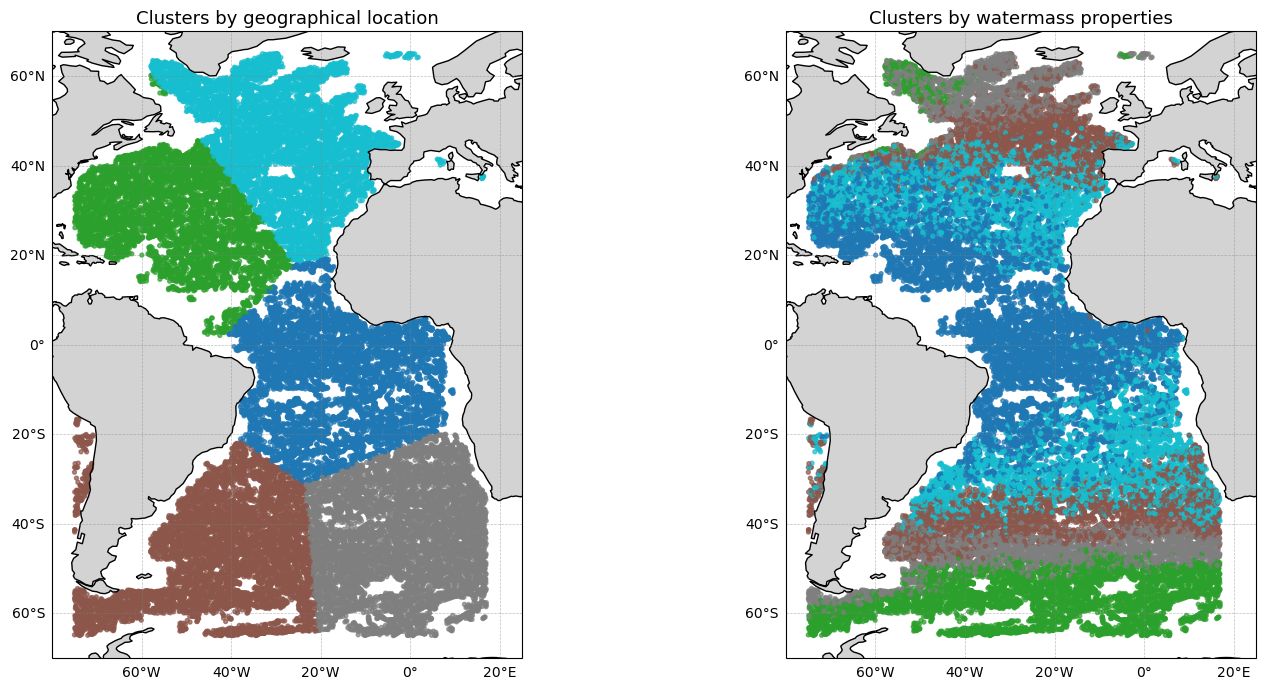

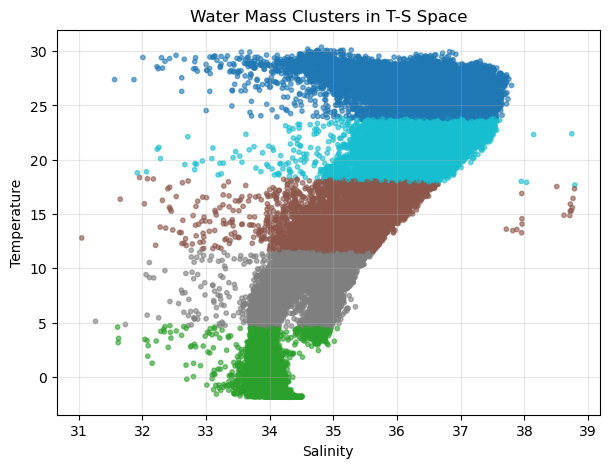

In [4]:
from sklearn.cluster import KMeans

# Prepare surface data for clustering
surf_idx = 0
T_surf = data[:, surf_idx, 0]
S_surf = data[:, surf_idx, 1]
valid_surf = np.isfinite(T_surf) & np.isfinite(S_surf)

# Features for clustering
X_geo = np.column_stack([da.LONGITUDE[valid_surf], da.LATITUDE[valid_surf]])
X_ts = np.column_stack([T_surf[valid_surf], S_surf[valid_surf]])

# K-Means clustering
n_clusters = 5
kmeans_geo = KMeans(n_clusters=n_clusters, random_state=SEED).fit(X_geo)
kmeans_ts = KMeans(n_clusters=n_clusters, random_state=SEED).fit(X_ts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Geographic Clusters
axes[0].set_extent([-80, 25, -70, 70], crs=ccrs.PlateCarree())
axes[0].add_feature(cfeature.LAND, facecolor='lightgray')
axes[0].add_feature(cfeature.COASTLINE)
gl0 = axes[0].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl0.top_labels = gl0.right_labels = False
sc0 = axes[0].scatter(da.LONGITUDE[valid_surf], da.LATITUDE[valid_surf], s=8, c=kmeans_geo.labels_, 
                      cmap='tab10', alpha=0.7, transform=ccrs.PlateCarree())
axes[0].set_title('Clusters by geographical location', fontsize=13)

# T/S Water Mass Clusters
axes[1].set_extent([-80, 25, -70, 70], crs=ccrs.PlateCarree())
axes[1].add_feature(cfeature.LAND, facecolor='lightgray')
axes[1].add_feature(cfeature.COASTLINE)
gl1 = axes[1].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = gl1.right_labels = False
sc1 = axes[1].scatter(da.LONGITUDE[valid_surf], da.LATITUDE[valid_surf], s=8, c=kmeans_ts.labels_, 
                       cmap='tab10', alpha=0.7, transform=ccrs.PlateCarree())
axes[1].set_title('Clusters by watermass properties', fontsize=13)

plt.tight_layout()
plt.show()

# T-S plot of clusters
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_ts[:, 1], X_ts[:, 0], c=kmeans_ts.labels_, cmap='tab10', s=10, alpha=0.6)
ax.set_xlabel('Salinity')
ax.set_ylabel('Temperature')
ax.set_title('Water Mass Clusters in T-S Space')
ax.grid(alpha=0.3)
plt.show()

cluster_onehot = pd.get_dummies(kmeans_ts.labels_).values
n_profiles = data.shape[0]
full_cluster_feat = np.zeros((n_profiles, n_clusters))
full_cluster_feat[valid_surf] = cluster_onehot
n_depths = data.shape[1]
pointwise_clusters = np.repeat(full_cluster_feat, n_depths, axis=0)

The results clearly show the difference between artificially defined geographic boundaries and natural boundaries. Geographic clustering exhibits a box shape, while water mass clustering reveals a zonal distribution, consistent with the Earth's major climate zones. 

## 2.3 Regression: Predict Salinity from Temperature and Depth

In fact, as can be seen from the T-S diagram, when temperature and depth are the same (same y-value, same color), multiple salinities are represented in the data. This illustrates that using only temperature or depth to predict salinity will introduce errors. So how large is this error? I will use a simple MLP model to verify this question below.

The model constructs a four-layer MLP via PyTorch, utilizing a **128-64-32** architecture with **ReLU** activations. It employs a DataLoader for mini-batching (**batchsize=512**) to handle large Argo datasets without memory exhaustion. During training, the **Adam** optimizer minimizes **MSE loss**. Finally, the model aggregates validation predictions and converts them to arrays.

In the data preparation, firstly, I flattened the Atlantic Argo profiles and removed invalid values. To accelerate training while maintaining accuracy, I randomly subsampled 80,000 points from the observations (I have tried using all the data in the training, and the results are not significantly different.). I then conducted experiments for two input schemes: **1.Temperature-only** and **2. Temperature + Depth**. Partitioning the data into a 70:15:15 ratio for training, validation and testing. All input features and salinity labels were normalized using StandardScaler to ensure different physical variables remained on the same scale. Finally, the data were converted into PyTorch tensors for mini-batch training over 200 epochs and output predictions for performance evaluation.

In [5]:
class MLP_argo(nn.Module):
    def __init__(self, in_dim, out_dim=1):
        super(MLP_argo, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(), 
            nn.Linear(32, out_dim)
        )
    def forward(self, x):
        out = self.layers(x)
        return out


def training(X_train, Y_train, X_valid, Y_valid,
             num_epochs=200, batch_size=512):
    
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(TensorDataset(X_valid, Y_valid), batch_size=batch_size, shuffle=False)

    model = MLP_argo(in_dim=X_train.shape[1]).to(DEVICE)
    learning_rate = 1e-3
    J = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    print(f"model details: {model}")
    print(" ")
    print(f"optimizer details: {optimizer}")
    print(" ")
    
    train_losses = []
    valid_losses = [] 
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            optimizer.zero_grad()
            pred = model(xb)
            loss = J(pred, yb.view(-1, 1))
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
        
        epoch_loss = running_loss / len(X_train)
        train_losses.append(epoch_loss)
        
        model.eval()
        running_valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                loss = J(pred, yb.view(-1, 1))
                running_valid_loss += loss.item() * xb.size(0)
        
        epoch_valid_loss = running_valid_loss / len(X_valid)
        valid_losses.append(epoch_valid_loss)
        
        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {epoch_loss:.6f} | Valid Loss: {epoch_valid_loss:.6f}")
            
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(DEVICE)
            pred = model(xb)
            all_preds.append(pred.cpu())
            all_trues.append(yb) 

    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_true = torch.cat(all_trues, dim=0).numpy()
    
    return model, train_losses, valid_losses, y_pred, y_true

In [6]:
train_ratio = 0.7
valid_ratio = 0.15
test_ratio = 0.15
test_valid_ratio = valid_ratio + test_ratio

t_all = data[:, :, 0].ravel() # temperature
s_all = data[:, :, 1].ravel() # salinity (target)
d_all = np.tile(depth, data.shape[0]) # depth (repeated for each profile)
mask = np.isfinite(t_all) & np.isfinite(s_all)
t_clean, s_clean, d_clean = t_all[mask], s_all[mask], d_all[mask]
clusters_clean = pointwise_clusters[mask]

X_all_raw = np.column_stack([t_clean, d_clean, clusters_clean])
y_all_raw = s_clean

# Subsample to 80000 to keep training time reasonable on Colab
n_sub = 80000
idx_sub = rng.choice(len(y_all_raw), size=n_sub, replace=False)

X_sub = X_all_raw[idx_sub]
y_sub = y_all_raw[idx_sub]

X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(X_sub, y_sub, test_size=test_valid_ratio, random_state=SEED)
X_test_raw, X_valid_raw, Y_test_raw, Y_valid_raw = train_test_split(X_test_raw, Y_test_raw, test_size=valid_ratio/test_valid_ratio, random_state=SEED)

In [7]:
# This cell takes quite long to run

X_train_t = X_train_raw[:, 0:1]
X_valid_t = X_valid_raw[:, 0:1]
X_test_t  = X_test_raw[:, 0:1]

scaler_xt = StandardScaler().fit(X_train_t)
X_train_t = torch.FloatTensor(scaler_xt.transform(X_train_t))
X_valid_t = torch.FloatTensor(scaler_xt.transform(X_valid_t))
X_test_t  = torch.FloatTensor(scaler_xt.transform(X_test_t))

scaler_y = StandardScaler().fit(Y_train_raw.reshape(-1, 1))
Y_train_t = torch.FloatTensor(scaler_y.transform(Y_train_raw.reshape(-1, 1)))
Y_valid_t = torch.FloatTensor(scaler_y.transform(Y_valid_raw.reshape(-1, 1)))
Y_test_t  = torch.FloatTensor(scaler_y.transform(Y_test_raw.reshape(-1, 1)))

model, train_Jt, valid_Jt, pred_t, true_t = training(X_train_t, Y_train_t, X_valid_t, Y_valid_t, num_epochs=200)

model details: MLP_argo(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
 
optimizer details: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
 
Epoch  20 | Train Loss: 0.236686 | Valid Loss: 0.241349
Epoch  40 | Train Loss: 0.235799 | Valid Loss: 0.237317
Epoch  60 | Train Loss: 0.236595 | Valid Loss: 0.237240
Epoch  80 | Train Loss: 0.235952 | Valid Loss: 0.237639
Epoch 100 | Train Loss: 0.235148 | Valid Loss: 0.236583
Epoch 120 | Train Loss: 0.235544 | Valid Loss: 0.238665
Epoch 140 | Train Loss: 0.235028 | Valid Lo

In [8]:
# This cell takes quite long to run

X_train_td = X_train_raw[:, 0:2]
X_valid_td = X_valid_raw[:, 0:2]
X_test_td  = X_test_raw[:, 0:2]

scaler_xtd = StandardScaler().fit(X_train_td)
X_train_td = torch.FloatTensor(scaler_xtd.transform(X_train_td))
X_valid_td = torch.FloatTensor(scaler_xtd.transform(X_valid_td))
X_test_td  = torch.FloatTensor(scaler_xtd.transform(X_test_td))

Y_train_td, Y_valid_td, Y_test_td = Y_train_t, Y_valid_t, Y_test_t

model, train_Jtd, valid_Jtd, pred_td, true_td = training(X_train_td, Y_train_td, X_valid_td, Y_valid_td, num_epochs=200)

model details: MLP_argo(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
 
optimizer details: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
 
Epoch  20 | Train Loss: 0.119408 | Valid Loss: 0.124201
Epoch  40 | Train Loss: 0.118330 | Valid Loss: 0.121567
Epoch  60 | Train Loss: 0.117498 | Valid Loss: 0.122019
Epoch  80 | Train Loss: 0.118283 | Valid Loss: 0.122138
Epoch 100 | Train Loss: 0.116782 | Valid Loss: 0.123046
Epoch 120 | Train Loss: 0.116675 | Valid Loss: 0.121219
Epoch 140 | Train Loss: 0.116758 | Valid Lo

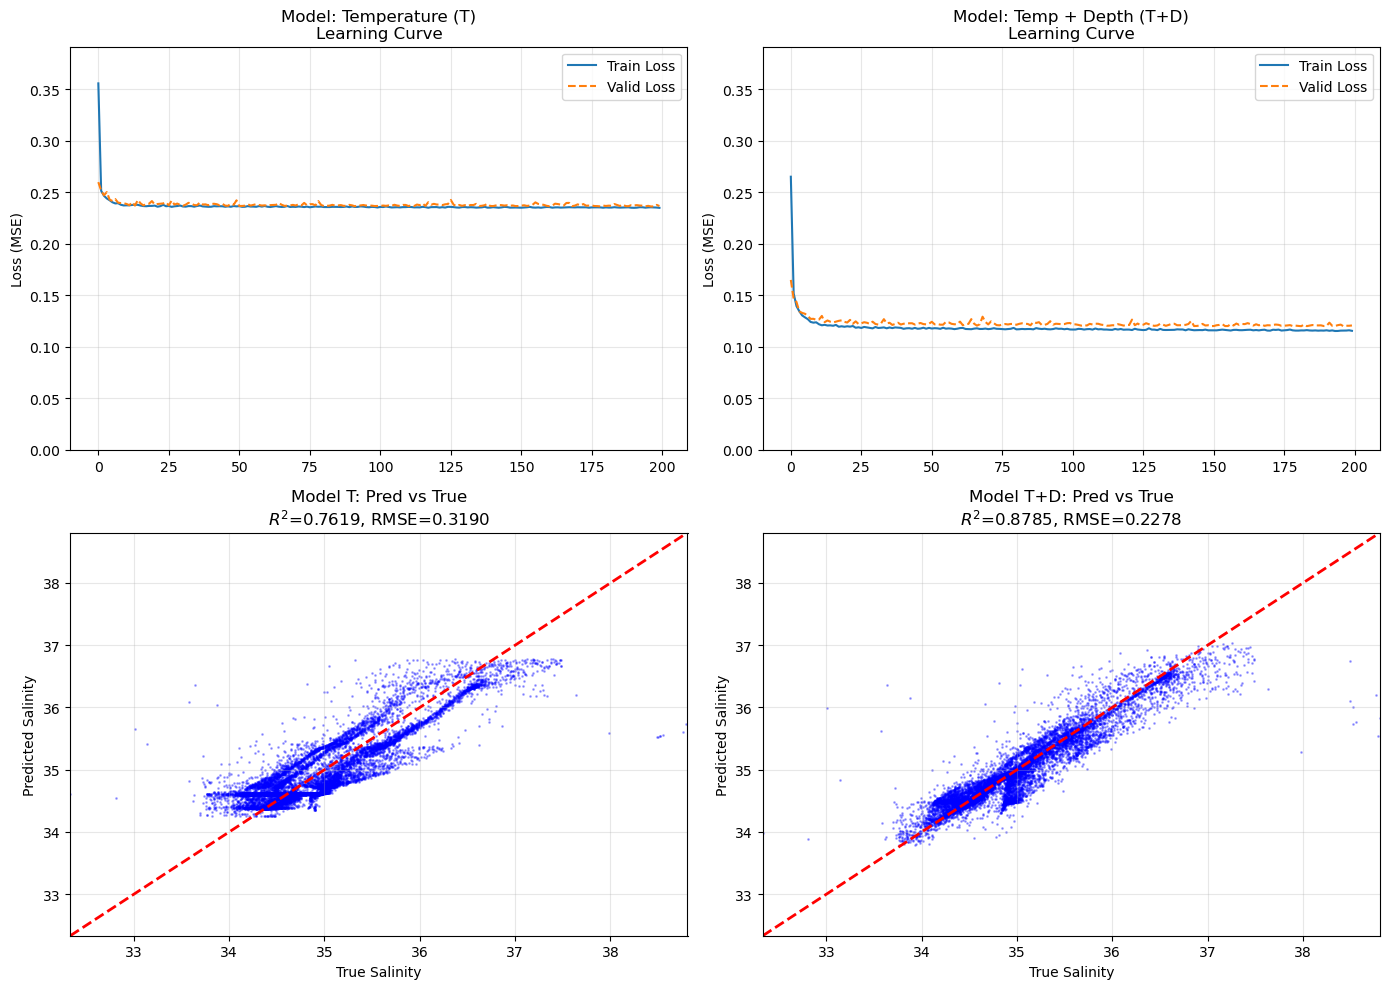

In [9]:
pred_t_phys = scaler_y.inverse_transform(pred_t)
true_t_phys = scaler_y.inverse_transform(true_t.reshape(-1, 1))
r2_t = r2_score(true_t_phys, pred_t_phys)
rmse_t = np.sqrt(mean_squared_error(true_t_phys, pred_t_phys))

pred_td_phys = scaler_y.inverse_transform(pred_td)
true_td_phys = scaler_y.inverse_transform(true_td.reshape(-1, 1))
r2_td = r2_score(true_td_phys, pred_td_phys)
rmse_td = np.sqrt(mean_squared_error(true_td_phys, pred_td_phys))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_Jt, label="Train Loss", color='C0')
axes[0, 0].plot(valid_Jt, label="Valid Loss", color='C1', linestyle='--')
axes[0, 0].set_title("Model: Temperature (T)\nLearning Curve")
axes[0, 0].set_ylabel("Loss (MSE)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_Jtd, label="Train Loss", color='C0')
axes[0, 1].plot(valid_Jtd, label="Valid Loss", color='C1', linestyle='--')
axes[0, 1].set_title("Model: Temp + Depth (T+D)\nLearning Curve")
axes[0, 1].set_ylabel("Loss (MSE)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

max_loss = max(max(train_Jt), max(train_Jtd))
axes[0, 0].set_ylim(0, max_loss * 1.1)
axes[0, 1].set_ylim(0, max_loss * 1.1)

sal_min = min(true_t_phys.min(), true_td_phys.min())
sal_max = max(true_t_phys.max(), true_td_phys.max())

axes[1, 0].scatter(true_t_phys, pred_t_phys, s=1, alpha=0.3, color='blue')
axes[1, 0].plot([sal_min, sal_max], [sal_min, sal_max], 'r--', lw=2)
axes[1, 0].set_title(f"Model T: Pred vs True\n$R^2$={r2_t:.4f}, RMSE={rmse_t:.4f}")
axes[1, 0].set_xlabel("True Salinity")
axes[1, 0].set_ylabel("Predicted Salinity")
axes[1, 0].set_xlim(sal_min, sal_max)
axes[1, 0].set_ylim(sal_min, sal_max)
axes[1, 0].grid(alpha=0.3)


axes[1, 1].scatter(true_td_phys, pred_td_phys, s=1, alpha=0.3, color='blue')
axes[1, 1].plot([sal_min, sal_max], [sal_min, sal_max], 'r--', lw=2)
axes[1, 1].set_title(f"Model T+D: Pred vs True\n$R^2$={r2_td:.4f}, RMSE={rmse_td:.4f}")
axes[1, 1].set_xlabel("True Salinity")
axes[1, 1].set_ylabel("Predicted Salinity")
axes[1, 1].set_xlim(sal_min, sal_max)
axes[1, 1].set_ylim(sal_min, sal_max)
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

The results clearly identify Depth as an important physical variable. It boosted the $R^2$ from 0.76 to 0.87 and suppressed the RMSE from 0.31 to 0.22. This proves that by incorporating depth, the neural network can more accurately distinguish between different water masses, leading to far more precise salinity inversions.

## 2.4 Cluster-Based Regression: Predict Salinity from Temperature and Depth

As show in the previous Clustering section, I have already identified distinct water masses in the Atlantic with unique physical properties. Now, I want to incorporate this information as a key variable to see if it improves the predictive model.

Instead of simply feeding the cluster labels as numerical inputs into a single model, I chose a more targeted strategy that **training specialized prediction models independently for each water mass**. This approach allows the model to focus exclusively on the specific oceanographic characteristics of a particular region. By partitioning the data this way, each expert model avoids the interference of data from other water masses, enabling it to learn the local Temperature-Salinity mapping more effectively.

In [10]:
# This cell takes quite long to run

ensemble_models = {}
ensemble_results = []

n_clusters = 4 

for i in range(n_clusters):
    print(f"Training Model for Cluster {i}")
    train_mask = (X_train_raw[:, 2 + i] == 1)
    valid_mask = (X_valid_raw[:, 2 + i] == 1)
    
    X_train_c = X_train_raw[train_mask, :2]
    Y_train_c = Y_train_raw[train_mask]
    
    X_valid_c = X_valid_raw[valid_mask, :2]
    Y_valid_c = Y_valid_raw[valid_mask]

    scaler_x = StandardScaler().fit(X_train_c)
    scaler_y = StandardScaler().fit(Y_train_c.reshape(-1, 1))
    
    X_train_t = torch.FloatTensor(scaler_x.transform(X_train_c))
    Y_train_t = torch.FloatTensor(scaler_y.transform(Y_train_c.reshape(-1, 1)))
    X_valid_t = torch.FloatTensor(scaler_x.transform(X_valid_c))
    Y_valid_t = torch.FloatTensor(scaler_y.transform(Y_valid_c.reshape(-1, 1)))

    model_e, t_loss, v_loss, pred_e, true_e = training(X_train_t, Y_train_t, X_valid_t, Y_valid_t, num_epochs=200)
    
    pred_phys = scaler_y.inverse_transform(pred_e)
    true_phys = scaler_y.inverse_transform(true_e.reshape(-1, 1))
    
    ensemble_models[i] = {'model': model_e, 'scaler_x': scaler_x, 'scaler_y': scaler_y}
    ensemble_results.append((true_phys, pred_phys))

all_true_ensemble = np.vstack([res[0] for res in ensemble_results])
all_pred_ensemble = np.vstack([res[1] for res in ensemble_results])

r2_ensemble = r2_score(all_true_ensemble, all_pred_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(all_true_ensemble, all_pred_ensemble))

Training Model for Cluster 0
model details: MLP_argo(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
 
optimizer details: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
 
Epoch  20 | Train Loss: 0.067129 | Valid Loss: 0.077832
Epoch  40 | Train Loss: 0.065451 | Valid Loss: 0.071541
Epoch  60 | Train Loss: 0.063942 | Valid Loss: 0.069599
Epoch  80 | Train Loss: 0.062490 | Valid Loss: 0.069849
Epoch 100 | Train Loss: 0.061939 | Valid Loss: 0.069456
Epoch 120 | Train Loss: 0.062733 | Valid Loss: 0.069655
Epoch 140 | Tr

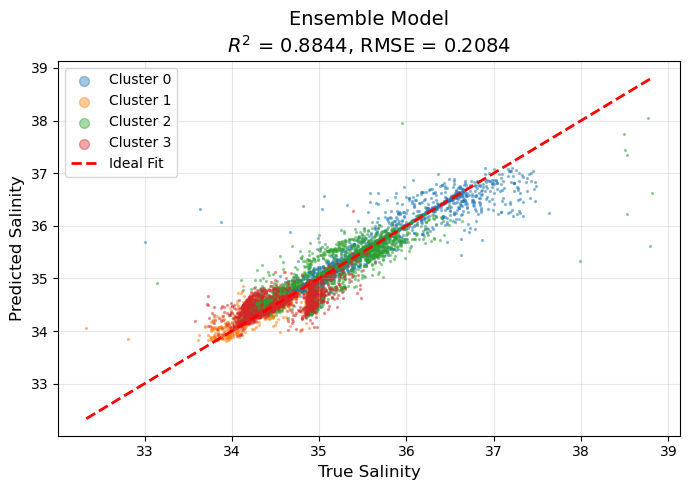

In [11]:
plt.figure(figsize=(7, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for i, (true_p, pred_p) in enumerate(ensemble_results):
    plt.scatter(true_p, pred_p, s=2, alpha=0.4, color=colors[i], label=f'Cluster {i}')

sal_min = all_true_ensemble.min()
sal_max = all_true_ensemble.max()
plt.plot([sal_min, sal_max], [sal_min, sal_max], 'r--', lw=2, label='Ideal Fit')

plt.title(f"Ensemble Model\n$R^2$ = {r2_ensemble:.4f}, RMSE = {rmse_ensemble:.4f}", fontsize=14)
plt.xlabel("True Salinity", fontsize=12)
plt.ylabel("Predicted Salinity", fontsize=12)
plt.legend(markerscale=5, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot above compares predicted versus true salinity for each of the four cluster-specific models. The ensemble achieves a clear improvement over a single global model that it get higher $R^2$ and the spread around the ideal diagonal is visibly reduced. These results also confirm that **grouping by water mass before regression is meaningful** that each specialised model avoids fitting across different correlation of temperature and salinity and improving overall prediction accuracy.

## 2.5 Autoencoders for profile dimension reduction

The previous regression models treat each depth point independently, ignoring the vertical continuity inherent in ocean profiles. An **autoencoder** offers a more elegant solution: it compresses an entire temperature profile into a compact latent representation and then reconstructs it, forcing the network to learn the most salient structural features of the water column.

The architecture consists of a symmetric **encoder–decoder** pair. The encoder progressively reduces the profile dimension through two hidden layers down to a **2-dimensional latent space**, while the decoder mirrors this structure to reconstruct the original profile. Training uses the **MSE  loss** with the **Adam** optimizer over 200 epochs. After training, the 2-D latent codes are coloured by latitude zone to examine whether the unsupervised representation naturally separates distinct water masses.

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=272, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=272, bias=True)
  )
)
Epoch   0 | Loss: 0.0569
Epoch  30 | Loss: 0.0077
Epoch  60 | Loss: 0.0072
Epoch  90 | Loss: 0.0070
Epoch 120 | Loss: 0.0080


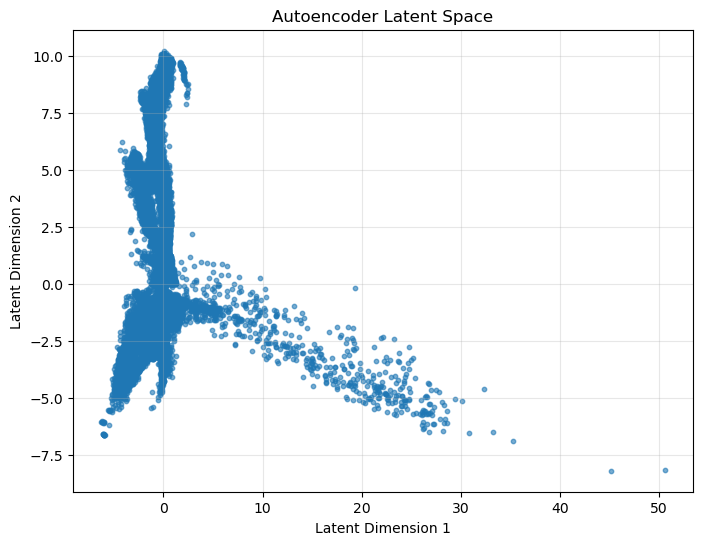

In [12]:
# This cell takes quite long to run

T_profiles = data[:, :, 0]
valid = np.all(np.isfinite(T_profiles), axis=1)
X = T_profiles[valid]

input_dim = X.shape[1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        hidden_dim1 = min(128, input_dim * 2)
        hidden_dim2 = min(64, hidden_dim1 // 2)
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

latent_dim = 2
ae = Autoencoder(input_dim=input_dim, latent_dim=latent_dim)

opt = optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(X_tensor), batch_size=64, shuffle=True)

print(ae)
for epoch in range(150):
    total_loss = 0
    for (xb,) in loader:
        opt.zero_grad()
        recon, _ = ae(xb)
        loss = criterion(recon, xb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d} | Loss: {total_loss/len(loader):.4f}")

ae.eval()
with torch.no_grad():
    _, z_ae = ae(X_tensor)
z_ae = z_ae.numpy()

plt.figure(figsize=(8, 6))
plt.scatter(z_ae[:, 0], z_ae[:, 1], s=10, alpha=0.6)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Autoencoder Latent Space')
plt.grid(alpha=0.3)
plt.show()

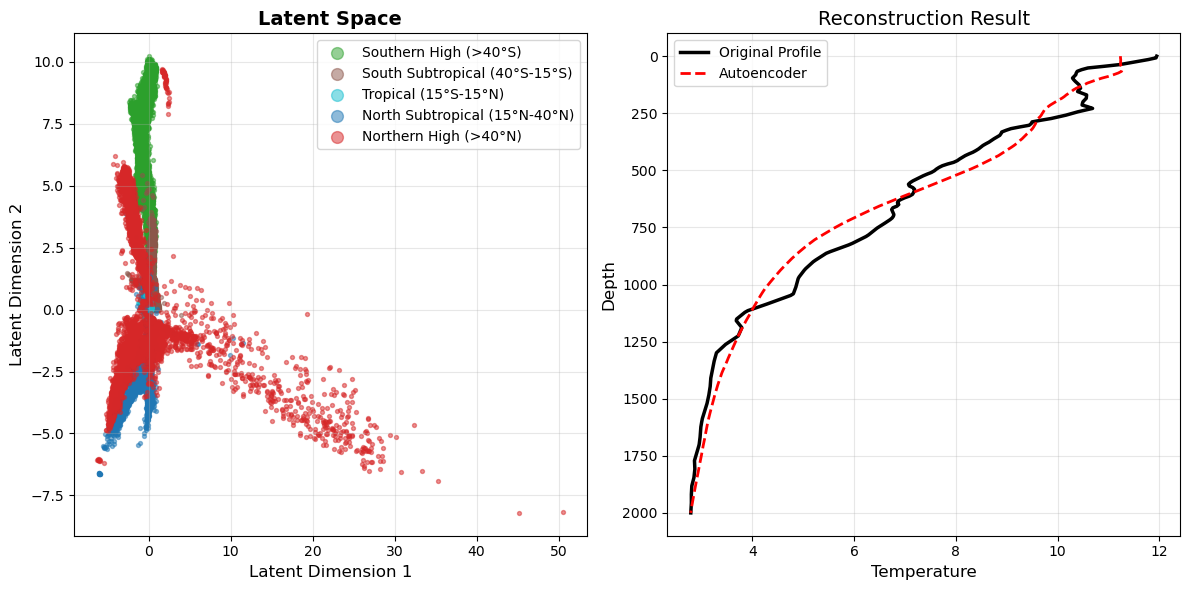

In [13]:
lat_valid = da.LATITUDE[valid].values

def get_lat_label(lat):
    if lat < -40: 
        return 'Southern High (>40°S)'
    elif lat < -15: 
        return 'South Subtropical (40°S-15°S)'
    elif lat < 15: 
        return 'Tropical (15°S-15°N)'
    elif lat < 40: 
        return 'North Subtropical (15°N-40°N)'
    else: 
        return 'Northern High (>40°N)'

lat_labels = np.array([get_lat_label(l) for l in lat_valid])
label_names = ['Southern High (>40°S)', 'South Subtropical (40°S-15°S)', 'Tropical (15°S-15°N)', 
               'North Subtropical (15°N-40°N)', 'Northern High (>40°N)']
ae.eval()
with torch.no_grad():
    X_recon_tensor, _ = ae(X_tensor)
X_recon_scaled = X_recon_tensor.numpy()
X_phys = scaler.inverse_transform(X_scaled)
X_recon_phys = scaler.inverse_transform(X_recon_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Latent Space
colors = ['#2ca02c', '#8c564b', '#17becf', '#1f77b4', '#d62728']
for i, name in enumerate(label_names):
    mask = lat_labels == name
    axes[0].scatter(z_ae[mask, 0], z_ae[mask, 1], s=8, alpha=0.5, color=colors[i], label=name)
axes[0].set_xlabel('Latent Dimension 1', fontsize=12)
axes[0].set_ylabel('Latent Dimension 2', fontsize=12)
axes[0].set_title('Latent Space', fontsize=14, fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].grid(alpha=0.3)

# Reconstruction Result
idx_sample = rng.choice(X.shape[0])
depth_plot = np.linspace(0, 2000, input_dim) 

axes[1].plot(X_phys[idx_sample], depth_plot, 'k-', lw=2.5, label='Original Profile')
axes[1].plot(X_recon_phys[idx_sample], depth_plot, 'r--', lw=2, label='Autoencoder')
axes[1].set_xlabel('Temperature', fontsize=12)
axes[1].set_ylabel('Depth', fontsize=12)
axes[1].set_title('Reconstruction Result', fontsize=14)
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

After completing the temperature profile reconstruction task using an autoencoder, I made minimal modifications to the model structure to achieve salinity prediction. I kept the overall encoder-decoder architecture unchanged, and only changed the decoder's output target from **reconstructing the input temperature profile** to **predicting the corresponding salinity profile**. This transformation converts the unsupervised feature learning model into a supervised regression model, enabling it to automatically learn the complex nonlinear mapping relationship between temperature and salinity. Compared with traditional point-wise regression methods, this profile-to-profile prediction approach better preserves the vertical continuity of ocean thermohaline structure, and utilizes the deep features extracted by the encoder to capture the unique thermohaline characteristics of different water masses.

In [14]:
# This cell takes quite long to run

S_profiles = data[:, :, 1] 

valid2 = np.all(np.isfinite(T_profiles) & np.isfinite(S_profiles), axis=1)
X_T = T_profiles[valid2]
y_S = S_profiles[valid2]

input_dim = X_T.shape[1]

X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(X_T, y_S, test_size=test_valid_ratio, random_state=SEED)
X_test_ae, X_valid_ae, y_test_ae, y_valid_ae = train_test_split(X_test_ae, y_test_ae, test_size=valid_ratio/test_valid_ratio, random_state=SEED)

scaler_T = StandardScaler().fit(X_train_ae)
scaler_S = StandardScaler().fit(y_train_ae)

Xtrain_ae = torch.FloatTensor(scaler_T.transform(X_train_ae))
Xvalid_ae = torch.FloatTensor(scaler_T.transform(X_valid_ae))
Xtest_ae = torch.FloatTensor(scaler_T.transform(X_test_ae))
ytrain_ae = torch.FloatTensor(scaler_S.transform(y_train_ae))
yvalid_ae = torch.FloatTensor(scaler_S.transform(y_valid_ae))
ytest_ae = torch.FloatTensor(scaler_S.transform(y_test_ae))


class Autoencoder2(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        hidden_dim1 = min(128, input_dim * 2)
        hidden_dim2 = min(64, hidden_dim1 // 2)
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x) 
        salinity_pred = self.decoder(z)
        return salinity_pred, z


model = Autoencoder2(input_dim=input_dim)
opt = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(Xtrain_ae, ytrain_ae), batch_size=64, shuffle=True)

print(model)

train_losses = []
val_losses = []

for epoch in range(150):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        opt.zero_grad()
        pred, _ = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred, _ = model(Xvalid_ae)
        val_loss = criterion(val_pred, yvalid_ae).item()
    
    train_losses.append(total_loss/len(loader))
    val_losses.append(val_loss)
    
    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Autoencoder2(
  (encoder): Sequential(
    (0): Linear(in_features=272, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=272, bias=True)
  )
)
Epoch   0 | Train Loss: 0.1418 | Val Loss: 0.0518
Epoch  30 | Train Loss: 0.0191 | Val Loss: 0.0154
Epoch  60 | Train Loss: 0.0143 | Val Loss: 0.0142
Epoch  90 | Train Loss: 0.0120 | Val Loss: 0.0129
Epoch 120 | Train Loss: 0.0129 | Val Loss: 0.0134


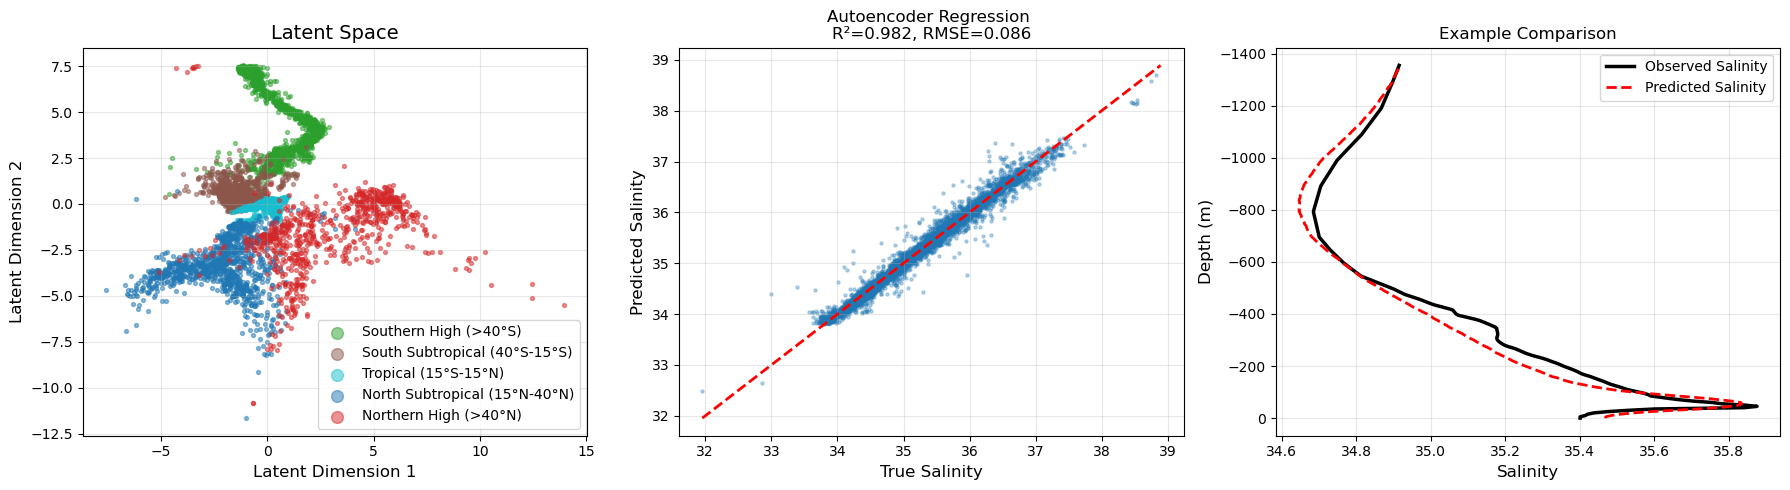

In [15]:
model.eval()
with torch.no_grad():
    y_pred_sc, z_ae2 = model(Xtest_ae)
y_pred_sc = y_pred_sc.cpu().numpy()
z_ae2 = z_ae2.cpu().numpy()
y_pred = scaler_S.inverse_transform(y_pred_sc)
y_true = y_test_ae

_, lat_test = train_test_split(lat_valid, test_size=test_valid_ratio, random_state=SEED)
lat_test, _ = train_test_split(lat_test, test_size=valid_ratio/test_valid_ratio, random_state=SEED)
lat_labels_test = np.array([get_lat_label(l) for l in lat_test])

r2_total = r2_score(y_true.ravel(), y_pred.ravel())
rmse_total = np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(label_names):
    mask = lat_labels_test == name
    axes[0].scatter(z_ae2[mask, 0], z_ae2[mask, 1], s=8, alpha=0.5, color=colors[i], label=name)
axes[0].set_xlabel('Latent Dimension 1', fontsize=12)
axes[0].set_ylabel('Latent Dimension 2', fontsize=12)
axes[0].set_title('Latent Space', fontsize=14)
axes[0].legend(markerscale=3)
axes[0].grid(alpha=0.3)

axes[1].scatter(y_true.ravel()[::100], y_pred.ravel()[::100], s=5, alpha=0.3)
min_max = [y_true.min(), y_true.max()]
axes[1].plot(min_max, min_max, 'r--', lw=2, label='1:1 Line')
axes[1].set_xlabel('True Salinity', fontsize=12)
axes[1].set_ylabel('Predicted Salinity', fontsize=12)
axes[1].set_title(f'Autoencoder Regression \nR²={r2_total:.3f}, RMSE={rmse_total:.3f}')
axes[1].grid(alpha=0.3)

depth = da.DEPTH[:-30].values
idx_sample = np.random.choice(y_true.shape[0])
axes[2].plot(y_true[idx_sample, :], depth, 'k-', lw=2.5, label='Observed Salinity')
axes[2].plot(y_pred[idx_sample, :], depth, 'r--', lw=2, label='Predicted Salinity')
axes[2].set_xlabel('Salinity', fontsize=12)
axes[2].set_ylabel('Depth (m)', fontsize=12)
axes[2].set_title('Example Comparison')
axes[2].invert_yaxis()
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The results show that the autoencoder-based salinity predictor successfully recovers the full vertical salinity profile from the temperature profile alone. It achieved a higher $R^2$ and a lower RMSE than the previous ensemble model.

## 3 Bacteria data

This dataset was provided by **Charmaine Yung**$^{[7]}$. The project collects biogeochemical measurements weekly from temperate coastal waters to study the seasonal interactions between physical, chemical, and biological parameters in coastal ecosystems (see table below). The dataset contains 151 valid observations covering approximately three years (daily values ranging from 19 to 1091).

| Symbol | Name |
| :--- | :--- |
| SampleID | A tag for the collected sample |
| YearDay | Number of days of the experiment |
| Bacteria_abundance | Bacterial cell number |
| Projected_Daily_Insolation | Solar heating |
| Temp | Water temperature |
| MLLW | Mean lower low water level |
| Salinity | Practical Salinity |
| Oxygen_Saturation | Dissolved oxygen saturation |
| pH | Seawater alkalinity |
| DIC | Dissolved Inorganic Carbon |
| Chlorophyll | Chlorophyll-a concentration |
| NH4 | Ammonium concentration |
| NO2.NO3 | Combined nitrite + nitrate concentration |
| PO4 | Phosphate concentration |
| SiO4 | Silicate concentration |

### 3.1 Preprocessing and Data Overview

First, seasonal labels were assigned based on the dates of the year and irrelevant columns were removed. To examine whether there were obvious seasonal trends among the data, a paired plot matrix was constructed to visualize the correlations between all remaining environmental variables, and points were colored seasonally to reveal potential seasonal differences in the variable relationships. Finally, time series of the three important variables (bacterial abundance, temperature and chlorophyll) were plotted as a function of the dates of the experiment.

In [16]:
bacteria_df = pd.read_csv(bacteria_loc, sep=r"\s+")

Mar = 31 + 28 + 1
Jun = Mar + 31 + 30 + 31
Sep = Jun + 30 + 31 + 31
Nov = Sep + 30 + 31 + 30

seasons = []
for i in range(bacteria_df["YearDay"].size):
    day = bacteria_df["YearDay"][i]
    if ( day % 365 >= Mar ) & ( day % 365 <  Jun ):
        seasons.append("spring")
    elif ( day % 365 >= Jun ) & ( day % 365 <  Sep ):
        seasons.append("summer")
    elif ( day % 365 >= Sep ) & ( day % 365 <  Nov ):
        seasons.append("autumn")
    else:
        seasons.append("winter")
bacteria_df["seasons"] = seasons
bacteria_df = bacteria_df.drop(labels=["SampleID", "Projected_Daily_Insolation", "MLLW"], axis=1)
bacteria_df = bacteria_df.sort_values('YearDay')

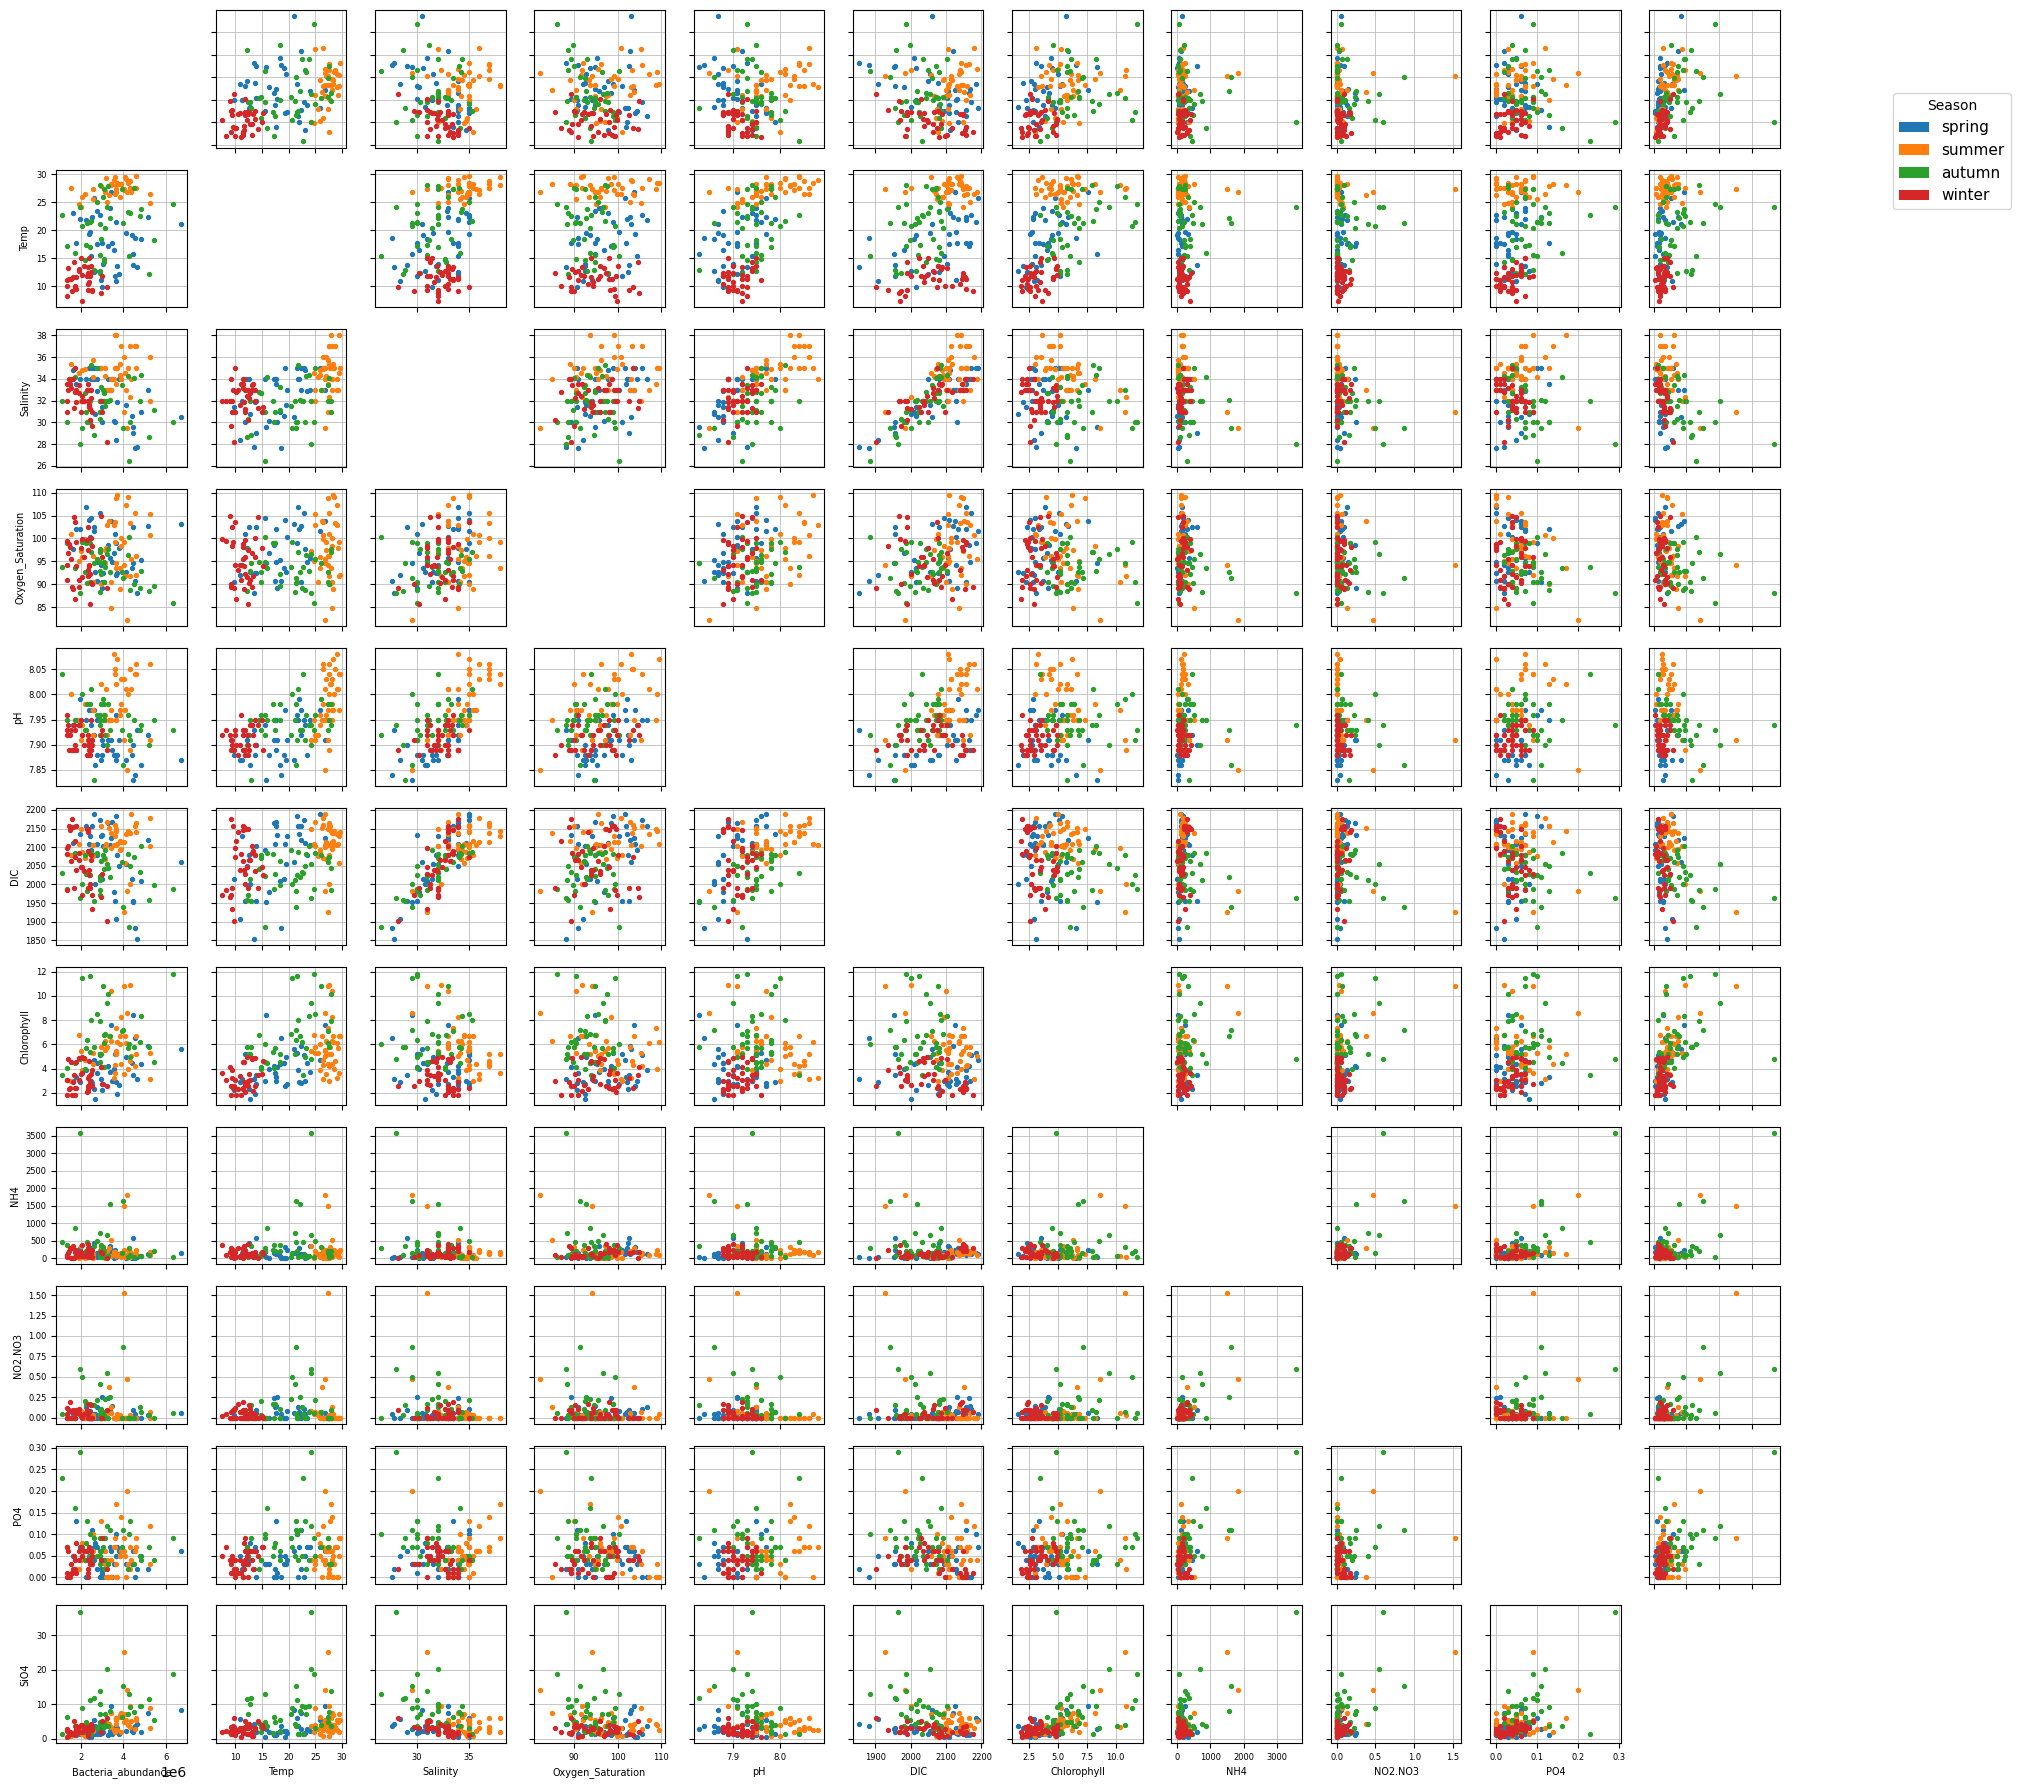

In [17]:
num_vars = ['Bacteria_abundance', 'Temp', 'Salinity', 'Oxygen_Saturation', 'pH',
            'DIC', 'Chlorophyll', 'NH4', 'NO2.NO3', 'PO4', 'SiO4']
season_colors = {'spring': 'C0', 'summer': 'C1', 'autumn': 'C2', 'winter': 'C3'}

fig, axes = plt.subplots(len(num_vars), len(num_vars), figsize=(18, 18))

for i, v1 in enumerate(num_vars):
    for j, v2 in enumerate(num_vars):
        ax = axes[i, j]
        if i == j:
            ax.axis('off')
        else:
            for s, c in season_colors.items():
                sub = bacteria_df.loc[bacteria_df['seasons'] == s, [v2, v1]].dropna()
                ax.scatter(sub[v2], sub[v1], s=8, color=c, zorder=2)
        if i == len(num_vars) - 1:
            ax.set_xlabel(v2, fontsize=7)
        else:
            ax.set_xticklabels([])    
        if j == 0:
            ax.set_ylabel(v1, fontsize=7)
        else:
            ax.set_yticklabels([])
            
        ax.tick_params(labelsize=6)
        ax.grid(lw=0.5, zorder=0)

handles = [Patch(fc=c, label=s) for s, c in season_colors.items()]
fig.legend(handles=handles, loc='upper left', fontsize=11, title='Season', bbox_to_anchor=(1.05, 0.95))

plt.tight_layout()
plt.show()

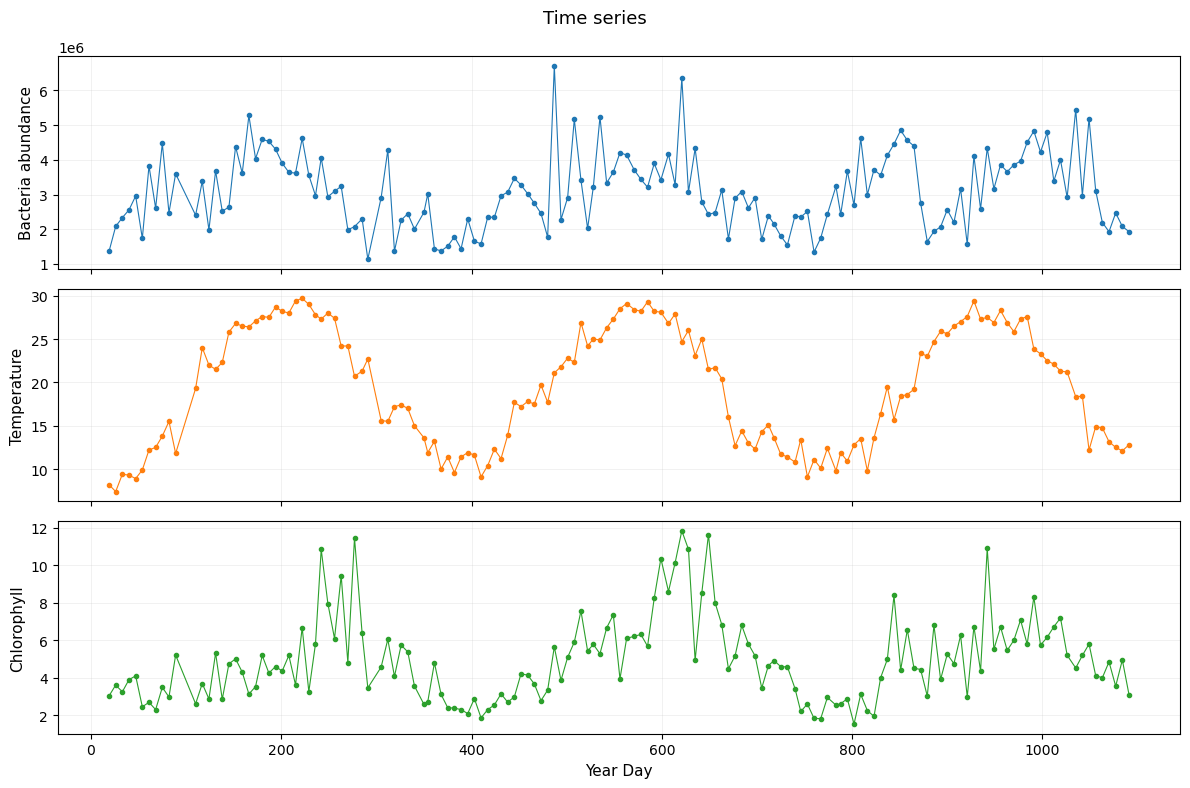

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(bacteria_df['YearDay'], bacteria_df['Bacteria_abundance'], 'C0o-', ms=3, lw=0.8)
axes[0].set_ylabel('Bacteria abundance', fontsize=11)
axes[0].grid(alpha=0.3, lw=0.4)

axes[1].plot(bacteria_df['YearDay'], bacteria_df['Temp'], 'C1o-', ms=3, lw=0.8)
axes[1].set_ylabel('Temperature', fontsize=11)
axes[1].grid(alpha=0.3, lw=0.4)

axes[2].plot(bacteria_df['YearDay'], bacteria_df['Chlorophyll'], 'C2o-', ms=3, lw=0.8)
axes[2].set_ylabel('Chlorophyll', fontsize=11)
axes[2].set_xlabel('Year Day', fontsize=11)
axes[2].grid(alpha=0.3, lw=0.4)

plt.suptitle('Time series', fontsize=13)
plt.tight_layout()
plt.show()

The paired plot matrix illustrates that temperature is the primary driver of seasonal differences, with summer (orange) and winter (red) samples forming distinctly separate clusters along the temperature axis. The time series plots show that the annual cyclical variation in water temperature is the most pronounced and remains stable over the three years. Bacterial abundance and chlorophyll concentration exhibit significant seasonal dynamics, with values typically increasing in spring and summer, consistent with findings in the literature, although some short-term fluctuations exist. 

### 3.2 Classification: Predict Season from Environmental Variables

The analysis above demonstrates clear seasonal structure in the environmental data. This motivates a supervised classification task: can we reliably predict the **season** from the measured variables alone?

A compact three-layer **MLP classifier** (**32–16** hidden layer units with **ReLU** activations) is trained using **cross-entropy loss** and the **Adam** optimizer over 300 epochs. The ten environmental features (temperature, salinity, oxygen saturation, pH, DIC, chlorophyll, NH₄, NO₂+NO₃, PO₄, SiO₄) serve as inputs, and the four seasons (spring, summer, autumn, winter) are the class labels. Using a confusion matrix on the test set to assess per-season classification accuracy.

In [19]:
class MLP_cls(nn.Module):
    def __init__(self, in_dim, n_classes=4, dropout_p=0.4):
        super(MLP_cls, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            # nn.Linear(32, 16),
            # nn.ReLU(), 
            # nn.Dropout(dropout_p),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        out = self.layers(x)
        return out


def training_cls(X_train, Y_train, X_valid, Y_valid,
             num_epochs=200, batch_size=32, n_classes=4, device=DEVICE):
    
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(TensorDataset(X_valid, Y_valid), batch_size=batch_size, shuffle=False)

    model = MLP_cls(in_dim=X_train.shape[1], n_classes=n_classes).to(device)
    learning_rate = 1e-3
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    sched = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

    
    print(f"model details: {model}")
    print(" ")
    print(f"optimizer details: {optimizer}")
    print(" ")
    
    train_losses = []
    valid_losses = []
    valid_accs = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb.long())
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
        
        epoch_loss = running_loss / len(X_train)
        train_losses.append(epoch_loss)
        
        model.eval()
        running_valid_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb.long())
                running_valid_loss += loss.item() * xb.size(0)

                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
        
        epoch_valid_loss = running_valid_loss / len(X_valid)
        epoch_valid_acc = correct / total
        valid_losses.append(epoch_valid_loss)
        valid_accs.append(epoch_valid_acc)

        sched.step(epoch_valid_loss)
        
        if (epoch + 1) % 20 == 0:
           print(f"Epoch {epoch+1:3d} | Train Loss: {epoch_loss:.6f} | Valid Loss: {epoch_valid_loss:.6f} | Valid Acc: {epoch_valid_acc:.4f}")
            
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_trues.append(yb) 

    y_pred = torch.cat(all_preds, dim=0).detach().numpy()
    y_true = torch.cat(all_trues, dim=0).detach().numpy()
    
    return model, train_losses, valid_losses, valid_accs, y_pred, y_true


def eval_classifier(model, X_test, Y_test, device=DEVICE):
    model.eval()
    test_loader = DataLoader(
        TensorDataset(X_test, Y_test), 
        batch_size=512, 
        shuffle=False
    )
    
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_trues.append(yb)
            
    y_pred = torch.cat(all_preds, dim=0).detach().numpy()
    y_true = torch.cat(all_trues, dim=0).detach().numpy()
    
    acc = (y_pred == y_true).mean()
    
    return acc, y_pred, y_true

In [20]:
feature_cols = ['Temp', 'Salinity', 'Oxygen_Saturation', 'pH', 'DIC', 'Chlorophyll', 'NH4', 'NO2.NO3', 'PO4', 'SiO4']
target_col = 'seasons'
season_map = {'spring': 0, 'summer': 1, 'autumn': 2, 'winter': 3}

bacteria_df2 = bacteria_df[feature_cols + [target_col]].dropna()

Xc = bacteria_df2[feature_cols].values.astype(np.float32)
yc = np.array([season_map[s] for s in bacteria_df2['seasons']], dtype=np.int64)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(Xc, yc, test_size=0.3, random_state=SEED)
X_test_cls, X_valid_cls, y_test_cls, y_valid_cls = train_test_split(X_test_cls, y_test_cls, test_size=0.5, random_state=SEED)

scaler_cls = StandardScaler().fit(Xc)

Xtrain_cls = torch.FloatTensor(scaler_cls.transform(X_train_cls))
Xvalid_cls = torch.FloatTensor(scaler_cls.transform(X_valid_cls))
Xtest_cls = torch.FloatTensor(scaler_cls.transform(X_test_cls))
ytrain_cls = torch.LongTensor(y_train_cls)
yvalid_cls = torch.LongTensor(y_valid_cls)
ytest_cls = torch.LongTensor(y_test_cls)

model_cls, train_losses_cls, val_losses_cls, val_accs_cls, val_pred_cls, val_true_cls = training_cls(Xtrain_cls, ytrain_cls, Xvalid_cls, yvalid_cls,
                                                                                                     num_epochs=300, batch_size=32, n_classes=4)

model details: MLP_cls(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=16, out_features=4, bias=True)
  )
)
 
optimizer details: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
 
Epoch  20 | Train Loss: 1.272047 | Valid Loss: 1.331114 | Valid Acc: 0.5217
Epoch  40 | Train Loss: 0.893473 | Valid Loss: 1.211578 | Valid Acc: 0.5217
Epoch  60 | Train Loss: 0.713931 | Valid Loss: 1.221191 | Valid Acc: 0.5217
Epoch  80 | Train Loss: 0.742672 | Valid Loss: 1.271190 | Valid Acc: 0.6087
Epoch 100 | Train Loss: 0.673450 | Valid Loss: 1.273158 | Valid Acc: 0.6087

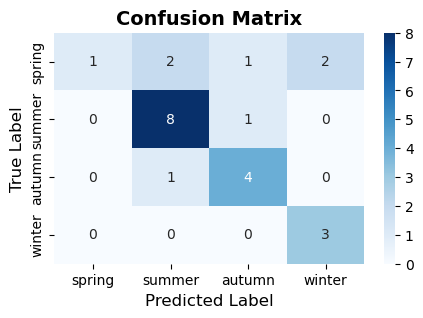

In [21]:
_, test_pred_cls, test_true_cls = eval_classifier(model_cls, Xtest_cls, ytest_cls)

cm = confusion_matrix(test_true_cls, test_pred_cls)
labels = ['spring', 'summer', 'autumn', 'winter']

plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

The confusion matrix shows that the MLP classifier performs well overall, with the majority of samples correctly classify along the diagonal. **Summer and winter** are classified almost perfectly, consistent with the paired plot analysis that showed these two seasons form the most distinct clusters in temperature–salinity space. **Spring and autumn** show a small number of misclassifications, which can be explained by the fact that the temperature and nutrient levels in these transitional seasons are at intermediate levels, making it difficult to distinguish them based on a single snapshot.

### 3.3 Time Series Forecasting

Environmental measurements collected at weekly intervals form a natural time series. Unlike the classification task, which treats each observation independently, recurrent neural networks (RNNs) can exploit temporal dependencies to forecast future states from a window of past observations.

Three recurrent architectures are compared: vanilla RNN, LSTM and GRU. All sharing the same design: 64 hidden layer units, 2 stacked layers and a fully-connected output head that predicts all variables simultaneously (multivariate-to-multivariate forecasting). A sliding window of length **seq_length** is used to construct input–output pairs. Bacterial abundance is **$log_{10}$ transformed** before training to stabilise the wide dynamic range of cell abundance. The dataset is split chronologically (no shuffling) into training and test segments to respect temporal ordering. Model performance is evaluated on the bacterial abundance output using $R^2$ and a time-series overlay plot.

In [22]:
def create_sequences(data, seq_length=1):
    x_dum, y_dum = [], []
    n_sample = data.shape[0] - seq_length
    for i in range(n_sample):
        x_dum.append(data[i:i+seq_length, :])
        y_dum.append(data[i+seq_length, :])
    return np.asarray(x_dum), np.asarray(y_dum)


target_col2 = 'Bacteria_abundance'
all_cols = feature_cols + [target_col2]

bacteria_df3 = (bacteria_df[all_cols + ['YearDay']].dropna().sort_values('YearDay').reset_index(drop=True))
bacteria_df4 = bacteria_df3[all_cols].values.astype(np.float32)
target_idx = all_cols.index(target_col2)
bacteria_df4[:, target_idx] = np.log10(bacteria_df4[:, target_idx])

scaler_ts = StandardScaler().fit(bacteria_df4)
bacteria_scaled = scaler_ts.transform(bacteria_df4)

seq_length = 3

X_seq, y_seq = create_sequences(bacteria_scaled, seq_length=5)

print(f"input shape is (batch_size, seq, dim) = {X_seq.shape}")
print(f"input shape is (batch_size, dim) = {y_seq.shape}")

n = len(y_seq)
n_train = int(n * 0.60)
n_valid = int(n * 0.20)

Xtrain_ts = torch.FloatTensor(X_seq[:n_train])
Xvalid_ts = torch.FloatTensor(X_seq[n_train:n_train+n_valid])
Xtest_ts = torch.FloatTensor(X_seq[n_train+n_valid:])
ytrain_ts = torch.FloatTensor(y_seq[:n_train])
yvalid_ts = torch.FloatTensor(y_seq[n_train:n_train+n_valid])
ytest_ts = torch.FloatTensor(y_seq[n_train+n_valid:])

input shape is (batch_size, seq, dim) = (146, 5, 11)
input shape is (batch_size, dim) = (146, 11)



Training RNN
Epoch   50 | Train Loss: 0.5832 | Val Loss: 0.5878
Epoch  100 | Train Loss: 0.4103 | Val Loss: 0.7258
Epoch  150 | Train Loss: 0.3084 | Val Loss: 0.7745
Epoch  200 | Train Loss: 0.2258 | Val Loss: 0.7959

Training LSTM
Epoch   50 | Train Loss: 0.6585 | Val Loss: 0.6586
Epoch  100 | Train Loss: 0.5312 | Val Loss: 0.6523
Epoch  150 | Train Loss: 0.4315 | Val Loss: 0.6586
Epoch  200 | Train Loss: 0.3210 | Val Loss: 0.7040

Training GRU
Epoch   50 | Train Loss: 0.6680 | Val Loss: 0.6385
Epoch  100 | Train Loss: 0.4941 | Val Loss: 0.6957
Epoch  150 | Train Loss: 0.3730 | Val Loss: 0.7990
Epoch  200 | Train Loss: 0.2943 | Val Loss: 0.9066


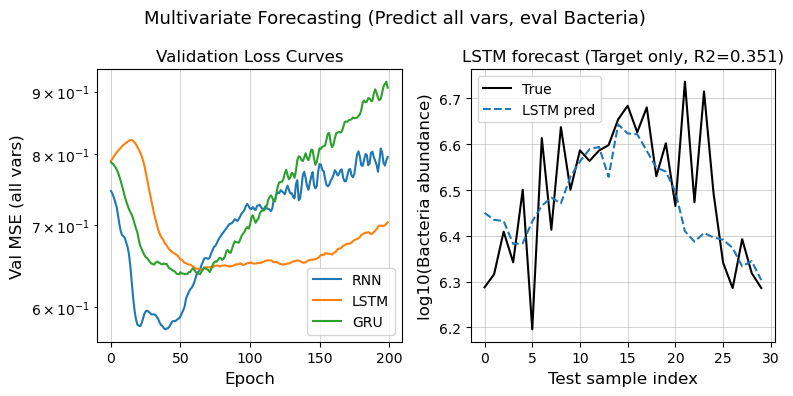

In [23]:
class RecurrentRegressor(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=64, num_layers=2,
                 rnn_type='LSTM', dropout=0.2):
        super().__init__()
        self.rnn_type = rnn_type
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (Batch size, seq_length, n_features)
        out, _ = self.rnn(x)
        last   = out[:, -1, :]
        return self.fc(last)

def train_model(model, Xtr, ytr, Xval, yval, lr=5e-4, epochs=200, batch_size=32):
    model = model.to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    
    loader = DataLoader(TensorDataset(Xtr.to(DEVICE), ytr.to(DEVICE)), batch_size=batch_size, shuffle=True)

    
    tr_loss, val_loss = [], []
    
    for ep in range(1, epochs+1):
        model.train()
        ep_l = 0.
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb)
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            ep_l += loss.item() * len(xb)
        tr_loss.append(ep_l / len(Xtr))
        
        model.eval()
        with torch.no_grad():
            val_l = crit(model(Xval.to(DEVICE)), yval.to(DEVICE)).item()
        val_loss.append(val_l)
        
        if ep % 50 == 0:
            print(f"Epoch {ep:4d} | Train Loss: {tr_loss[-1]:.4f} | Val Loss: {val_l:.4f}")
            
    return tr_loss, val_loss

def evaluate_reg(model, Xte, yte, scaler_full, target_col_idx):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(Xte.to(DEVICE)).cpu().numpy()
        true_scaled = yte.numpy()
        
    pred_full = scaler_full.inverse_transform(pred_scaled)
    true_full = scaler_full.inverse_transform(true_scaled)
    
    pred = pred_full[:, target_col_idx]
    true = true_full[:, target_col_idx]
    
    ss_res = ((true - pred) ** 2).sum()
    ss_tot = ((true - true.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(((true - pred) ** 2).mean())
    
    return r2, rmse, pred, true

    
n_feat = Xtrain_ts.shape[2]
n_out = n_feat

results_rnn = {}

for rtype in ['RNN', 'LSTM', 'GRU']:
    print(f'\nTraining {rtype}')
    model_r = RecurrentRegressor(n_feat, n_out, hidden_size=64, num_layers=2,
                                  rnn_type=rtype, dropout=0.3)
    tr_l, val_l = train_model(model_r, Xtrain_ts, ytrain_ts, Xvalid_ts, yvalid_ts,
                               lr=5e-4, epochs=200, batch_size=32)
    
    r2, rmse, pred, true = evaluate_reg(model_r, Xtest_ts, ytest_ts, scaler_ts, target_idx)
    
    results_rnn[rtype] = {'tr': tr_l, 'val': val_l, 'r2': r2,
                          'rmse': rmse, 'pred': pred, 'true': true}

colors_rnn = {'RNN': 'C0', 'LSTM': 'C1', 'GRU': 'C2'}
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for rtype in ['RNN', 'LSTM', 'GRU']:
    axes[0].plot(results_rnn[rtype]['val'], label=f'{rtype}',
                 color=colors_rnn[rtype], lw=1.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Val MSE (all vars)', fontsize=12)
axes[0].set_title('Validation Loss Curves', fontsize=12)
axes[0].legend(fontsize=10); axes[0].grid(lw=0.4); axes[0].set_yscale('log')

pred_lstm = results_rnn['LSTM']['pred'].ravel()
true_lstm = results_rnn['LSTM']['true'].ravel()
t_axis = np.arange(len(true_lstm))
axes[1].plot(t_axis, true_lstm,  'k-',   lw=1.5, label='True', zorder=3)
axes[1].plot(t_axis, pred_lstm,  'C0--', lw=1.5, label='LSTM pred', zorder=3)
axes[1].set_xlabel('Test sample index', fontsize=12)
axes[1].set_ylabel('log10(Bacteria abundance)', fontsize=12)
r2_lstm = results_rnn['LSTM']['r2']
axes[1].set_title(f'LSTM forecast (Target only, R2={r2_lstm:.3f})', fontsize=12)
axes[1].legend(fontsize=10); axes[1].grid(lw=0.4)

plt.suptitle('Multivariate Forecasting (Predict all vars, eval Bacteria)', fontsize=13)
plt.tight_layout(); plt.show()

The training loss indicates that all three recurrent architectures converged successfully, but exhibited some overfitting on the validation loss curve. Here, I use **LSTM**, which has the smallest overall validation loss, as a prediction example. This model can capture the overall trend of bacterial abundance relatively accurately, but it cannot obtain accurate results.


## 4 Conlusion

This notebook applied a range of neural network architectures to two different ocean datasets. 

**Argo salinity regression.**

* The MLP experiments confirmed that depth is an indispensable input.
* The cluster-based ensemble strategy further improved accuracy by training specialised models on individual water masses.
* The autoencoder analysis showed that a 2-D latent space can faithfully encode the vertical temperature structure while preserving physically meaningful water-mass boundaries, and the encoder–decoder framework was successfully repurposed for profile-to-profile salinity prediction.

**Marine bacteria classification and forecasting.**

* The MLP classifier achieved robust seasonal prediction from physicochemical variables, consistent with the known dominance of temperature in driving seasonal community transitions.
* The recurrent network comparison revealed that LSTM and GRU outperform vanilla RNN on the bacteria time series, with LSTM achieving the highest, underscoring the benefit of gated memory for irregular ecological signals.

## References

[1] National Oceanic and Atmospheric Administration Atlantic Oceanographic and Meteorological Laboratory. (2022, December 19). Argo Program. 

[2] Riser, S. C., Freeland, H. J., Roemmich, D., Wijffels, S., Troisi, A., Belbéoch, M., ... & Jayne, S. R. (2016). Fifteen years of ocean observations with the global Argo array. Nature Climate Change, 6(2), 145-153.

[3] Levitus, S., Antonov, J. I., Boyer, T. P., Baranova, O. K., Garcia, H. E., Locarnini, R. A., ... & Zweng, M. M. (2012). World ocean heat content and thermosteric sea level change (0–2000 m), 1955–2010. Geophysical Research Letters, 39(10).

[4] Gleckler, P. J., Durack, P. J., Stouffer, R. J., Johnson, G. C., & Forest, C. E. (2016). Industrial-era global ocean heat uptake doubles in recent decades. Nat. Climate Change, 6, 394–398.

[5] Desbruyères, D., Chafik, L., & Maze, G. (2021). A shift in the ocean circulation has warmed the subpolar North Atlantic Ocean since 2016. Communications Earth & Environment, 2(1), 48.

[6] Han, C., Bowen, M., & Sutton, P. (2025). Global observations of the response of the upper ocean to tropical cyclones based on Argo profiles. Journal of Geophysical Research: Oceans, 130(9), e2025JC022522.

[7] Ward, C. S., Yung, C. M., Davis, K. M., Blinebry, S. K., Williams, T. C., Johnson, Z. I., & Hunt, D. E. (2017). Annual community patterns are driven by seasonal switching between closely related marine bacteria. The ISME journal, 11(6), 1412-1422.

## Statment on AI Usage

The research ideas and methodology of this assignment are original student work. Claude AI was primarily used to enhance code quality, optimize visualization design and improve presentation result. All code was reviewed, validated and tested by the student to ensure correctness. 